In [2]:
import numpy as np
from scipy.signal import firwin2, freqz
import matplotlib.pyplot as plt

In [13]:
# ==============================
# SYSTEM PARAMETERS
# ==============================
Fs = 125e6        # ADC rate
R = 128            # CIC decimation
M = 1             # differential delay
N = 5             # CIC stages
Fs_cic = Fs / R   # after CIC

f_pass = 110e3    # passband edge
f_stop = 220e3    # stopband start

numtaps = 151      # FIR length (63–101 good)
outfile = "cic_compensation_2.coe"

In [14]:
# ==============================
# Frequency grid
# ==============================
f = np.linspace(0, Fs_cic/2, 4000)
Hcomp = np.ones(4000)
w = f/(Fs_cic/2)
print(w)

# ==============================
# CIC magnitude response
# ==============================
def cic_mag(f, Fs, R, M, N):
    eps = 1e-12
    num = np.sin(np.pi * f * R * M / Fs)
    den = np.sin(np.pi * f / Fs) + eps
    h = (num / (R * den)) ** N
    return np.abs(h)

Hcic = cic_mag(f, Fs, R, M, N)
Hcic[0] = 1.0  # avoid NaN at DC
print(Hcic)

[0.00000000e+00 2.50062516e-04 5.00125031e-04 ... 9.99499875e-01
 9.99749937e-01 1.00000000e+00]
[1.         0.99999824 0.99999867 ... 0.1048433  0.10471237 0.10458156]


In [15]:
# ==============================
# Desired compensation response
# ==============================
eps = 1e-8
Hcomp = 1 / (Hcic + eps)

# zero out after stopband
Hcomp[f > f_pass] = 0
# print(Hcomp)
# normalize
Hcomp /= np.max(Hcomp)
print(Hcomp)
# ==============================
# FIR design
# ==============================
b = firwin2(numtaps, w, Hcomp)
print(b)

[0.90070587 0.90070745 0.90070707 ... 0.         0.         0.        ]
[ 1.62714371e-04  3.31769811e-04  3.49027510e-04  1.97555990e-04
 -6.44025970e-05 -3.21928958e-04 -4.48786656e-04 -3.64704974e-04
 -8.09351048e-05  2.89882119e-04  5.72000961e-04  6.04195641e-04
  3.25398555e-04 -1.74584314e-04 -6.73421961e-04 -9.08264017e-04
 -7.07192963e-04 -9.74231964e-05  6.72469413e-04  1.22458406e-03
  1.22963724e-03  5.90615283e-04 -4.65585345e-04 -1.45365820e-03
 -1.84404022e-03 -1.33581978e-03 -5.22890391e-05  1.45727431e-03
  2.44071420e-03  2.30708918e-03  9.60371801e-04 -1.07772892e-03
 -2.85092797e-03 -3.40482508e-03 -2.28346441e-03  1.65235032e-04
  2.86036012e-03  4.44864238e-03  3.96714163e-03  1.39098209e-03
 -2.23187374e-03 -5.18103627e-03 -5.86072081e-03 -3.63346786e-03
  7.32539007e-04  5.27932909e-03  7.70944057e-03  6.51475124e-03
  1.84332656e-03 -4.36801967e-03 -9.15227685e-03 -9.88711369e-03
 -5.66768117e-03  2.01424007e-03  9.71191626e-03  1.35049623e-02
  1.09115082e-02  

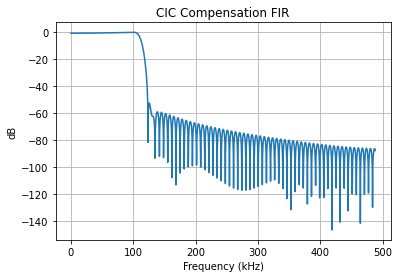

In [16]:
# ==============================
# Plot response
# ==============================
plt.figure()
plt.plot(f/1e3, 20*np.log10(np.abs(np.fft.rfft(b,8192))[:len(f)]))
plt.title("CIC Compensation FIR")
plt.xlabel("Frequency (kHz)")
plt.ylabel("dB")
plt.grid(True)
plt.show()

In [17]:
with open(outfile, "w") as f:
    f.write("; FIR Compiler coefficient file\n")
    f.write("radix = 10;\n")
    f.write("coefdata =\n")

    for i, coeff in enumerate(b):
        val = f"{coeff:.18f}".rstrip("0").rstrip(".")
        if i < len(b) - 1:
            f.write(val + ",\n")
        else:
            f.write(val + ";\n")

print(f"Correct FIR COE file written to {outfile}")

Correct FIR COE file written to cic_compensation_2.coe
